# Wine Dataset EDA 실습

이번 실습에서는 붓꽃 데이터에서 진행한 탐색적 데이터 분석 과정을 Wine 데이터에 적용해보겠습니다.

Wine 데이터에는 와인의 화학 성분을 나타내는 13개의 수치 변수와 3개의 클래스가 있습니다. 데이터 구조와 품질을 확인하고, 클래스별 분포와 변수 사이의 관계를 살펴보겠습니다.

1. 필요한 라이브러리 불러오기
2. Wine 데이터 불러오기
3. 데이터 구조 확인
4. 결측치와 중복 데이터 확인
5. 분석 변수 지정
6. 클래스 종류와 개수 확인
7. 기술통계량 확인
8. 클래스별 평균과 표준편차 확인
9. 변수별 전체 분포 확인
10. 클래스별 변수 분포 비교
11. Violin Plot
12. Pair Plot
13. 상관관계 분석
14. 주요 변수의 관계 확인
15. IQR 기반 이상치 탐지
16. 표준화된 클래스별 평균 비교
17. 변동계수 확인
18. 변수별 클래스 분리도 확인
19. EDA 결과 정리

## 1. 필요한 라이브러리 불러오기

`pandas`와 `numpy`는 데이터 처리에 사용하고, `matplotlib`과 `seaborn`은 그래프를 그리는 데 사용합니다. Wine 데이터는 `scikit-learn`에서 불러오겠습니다.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.datasets import load_wine
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Wine 데이터 불러오기

파일 경로가 실행 환경마다 달라지는 문제를 줄이기 위해 `scikit-learn`에서 제공하는 Wine 데이터를 사용하겠습니다. 클래스 번호는 보기 편하도록 이름으로 변환합니다.

In [2]:
wine = load_wine(as_frame=True)
df = wine.data.copy()
df["class_name"] = wine.target.map({i: f"class_{i}" for i in range(3)})
print("데이터 불러오기 완료")
display(df.head())

데이터 불러오기 완료


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


## 3. 데이터 구조 확인

데이터가 몇 개의 행과 열로 구성되어 있는지, 어떤 변수와 자료형이 있는지 확인해보겠습니다.

In [3]:
print("데이터 크기:", df.shape)
print("\n변수 이름")
print(df.columns.tolist())
print("\n자료형")
print(df.dtypes)
print("\n데이터 정보")
df.info()

데이터 크기: (178, 14)

변수 이름
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'class_name']

자료형
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
class_name                          str
dtype: object

데이터 정보
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------

## 4. 결측치와 중복 데이터 확인

분석에 앞서 값이 비어 있는 데이터와 같은 관측값이 반복된 경우가 있는지 확인하겠습니다.

In [4]:
print("변수별 결측치 개수")
display(df.isnull().sum().to_frame("missing_count"))
print("전체 결측치 개수:", int(df.isnull().sum().sum()))
print("중복 데이터 개수:", int(df.duplicated().sum()))

변수별 결측치 개수


,missing_count
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


전체 결측치 개수: 0
중복 데이터 개수: 0


## 5. 분석 변수 지정

Wine 데이터의 13개 수치 변수와 클래스 레이블을 따로 지정하겠습니다.

In [5]:
numeric_cols = list(wine.feature_names)
target_col = "class_name"
print("수치형 변수 개수:", len(numeric_cols))
print(numeric_cols)

수치형 변수 개수: 13
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


## 6. 클래스 종류와 개수 확인

각 클래스에 데이터가 몇 개씩 있는지 표와 막대그래프로 확인하겠습니다.

,count
class_name,
class_0,59
class_1,71
class_2,48


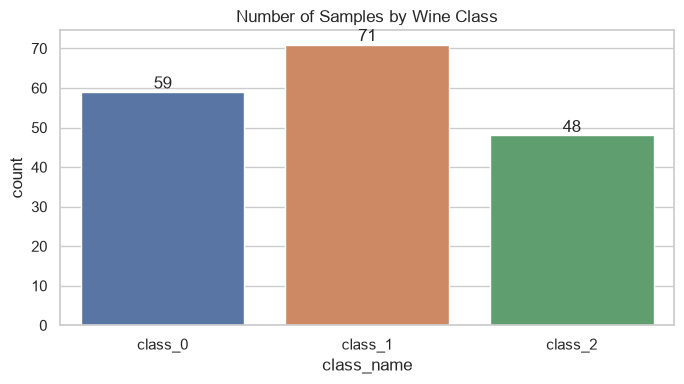

In [6]:
class_counts = df[target_col].value_counts().sort_index()
display(class_counts.to_frame("count"))
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x=target_col, order=class_counts.index, hue=target_col, legend=False)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Number of Samples by Wine Class")
plt.tight_layout()
plt.show()

## 7. 기술통계량 확인

평균, 표준편차, 최솟값, 사분위수와 최댓값을 확인해 데이터의 범위와 분포를 살펴보겠습니다.

In [7]:
display(df[numeric_cols].describe().round(3))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


## 8. 클래스별 평균과 표준편차 확인

클래스에 따라 평균 차이가 큰 변수는 와인 클래스를 구분하는 데 도움이 될 가능성이 있습니다.

In [8]:
print("클래스별 평균")
display(df.groupby(target_col)[numeric_cols].mean().round(3))
print("클래스별 표준편차")
display(df.groupby(target_col)[numeric_cols].std().round(3))

클래스별 평균


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
class_name,,,,,,,,,,,,,
class_0,13.745,2.011,2.456,17.037,106.339,2.840,2.982,0.290,1.899,5.528,1.062,3.158,1115.712
class_1,12.279,1.933,2.245,20.238,94.549,2.259,2.081,0.364,1.630,3.087,1.056,2.785,519.507
class_2,13.154,3.334,2.437,21.417,99.312,1.679,0.781,0.448,1.154,7.396,0.683,1.684,629.896


클래스별 표준편차


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
class_name,,,,,,,,,,,,,
class_0,0.462,0.689,0.227,2.546,10.499,0.339,0.397,0.070,0.412,1.239,0.116,0.357,221.521
class_1,0.538,1.016,0.315,3.350,16.753,0.545,0.706,0.124,0.602,0.925,0.203,0.497,157.211
class_2,0.530,1.088,0.185,2.258,10.890,0.357,0.294,0.124,0.409,2.311,0.114,0.272,115.097


## 9. 변수별 전체 분포 확인

히스토그램을 이용하여 13개 변수의 전체적인 분포를 한 번에 확인하겠습니다.

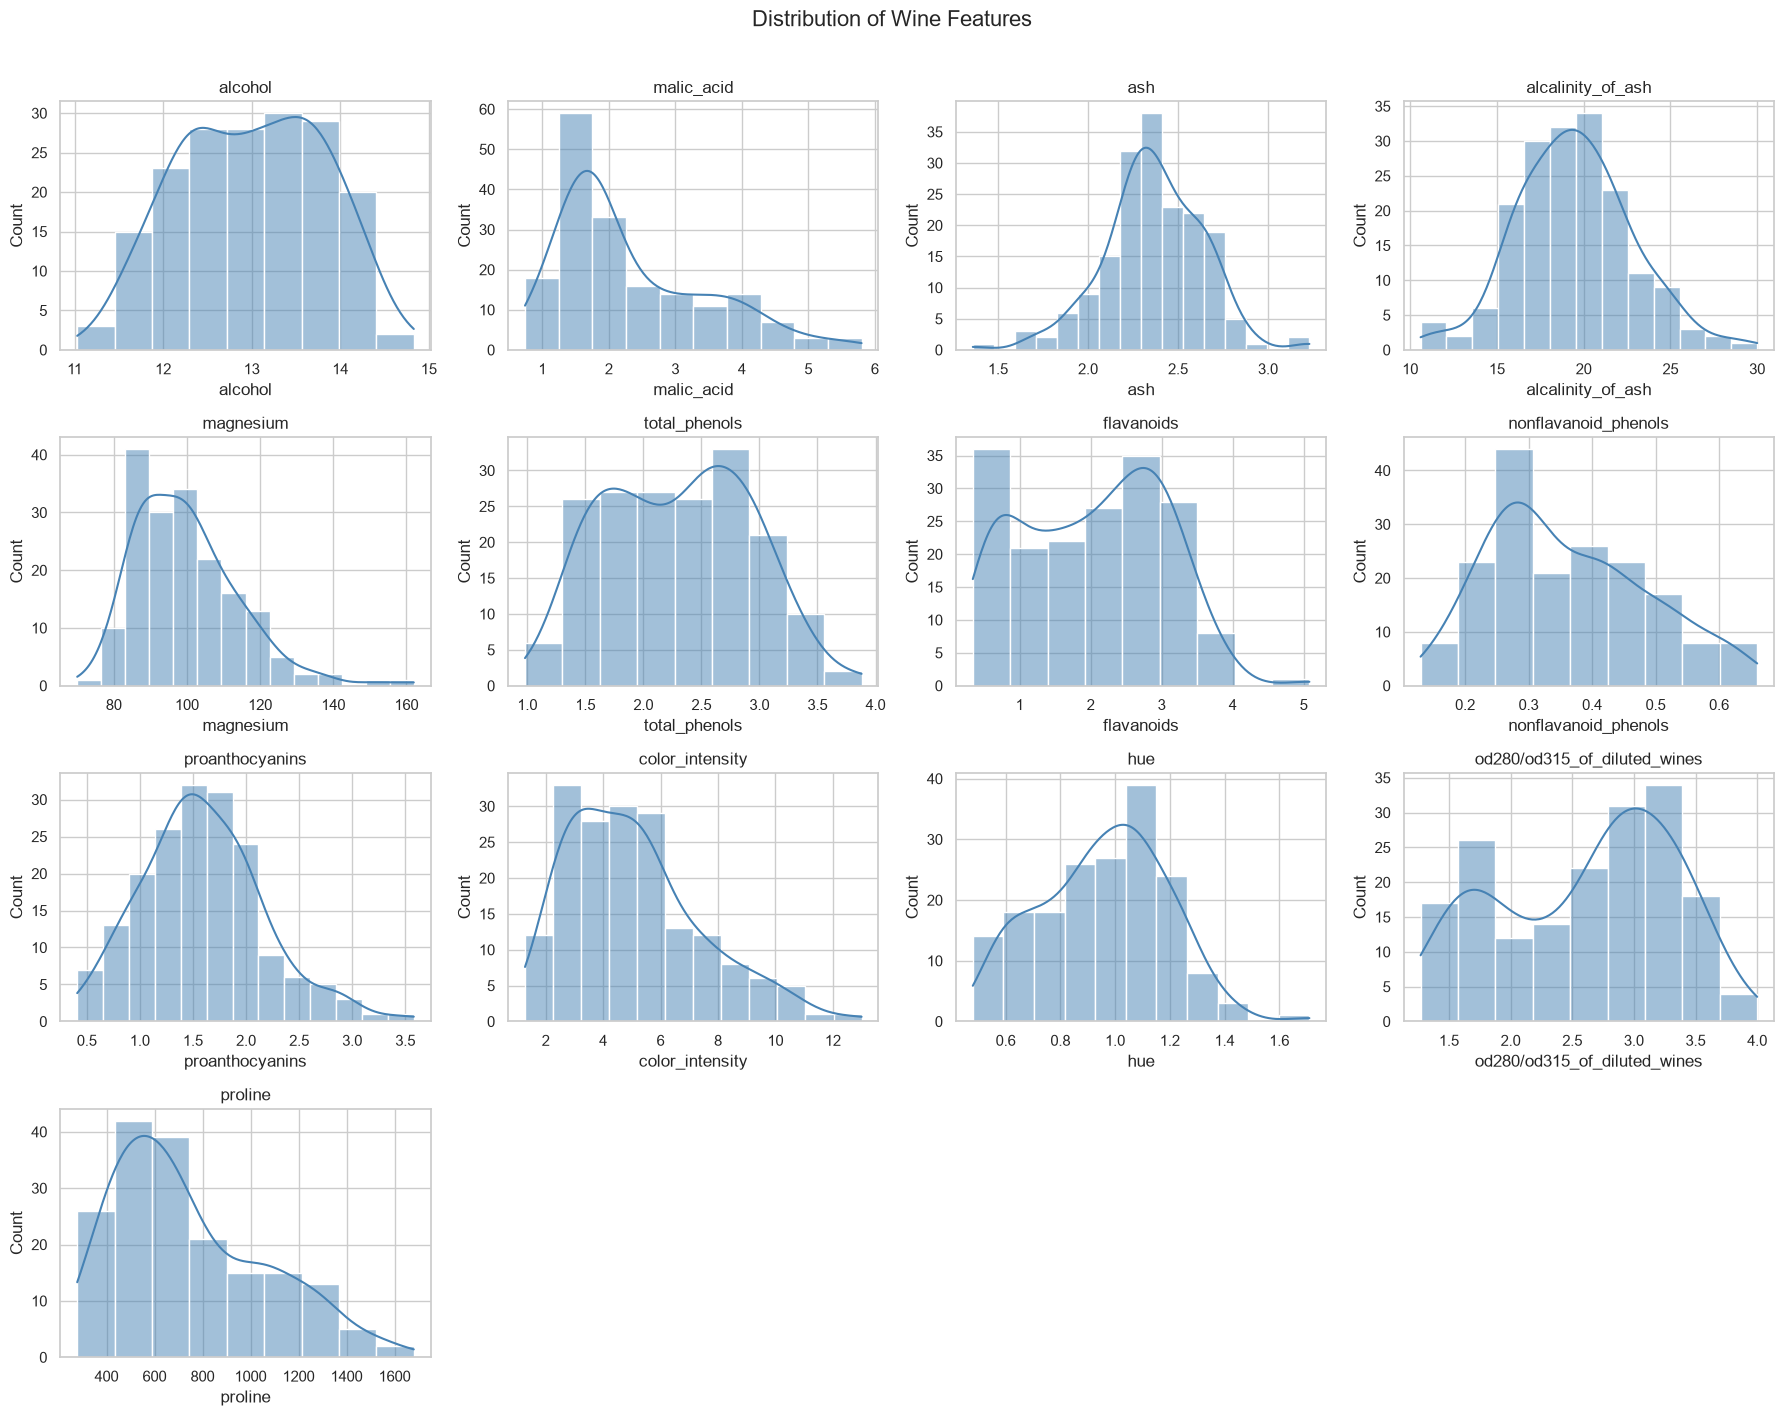

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
for i in range(len(numeric_cols), len(axes)):
    axes[i].axis("off")
fig.suptitle("Distribution of Wine Features", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 10. 클래스별 변수 분포 비교

Box Plot을 이용하여 각 변수의 중앙값과 범위를 클래스별로 비교하겠습니다.

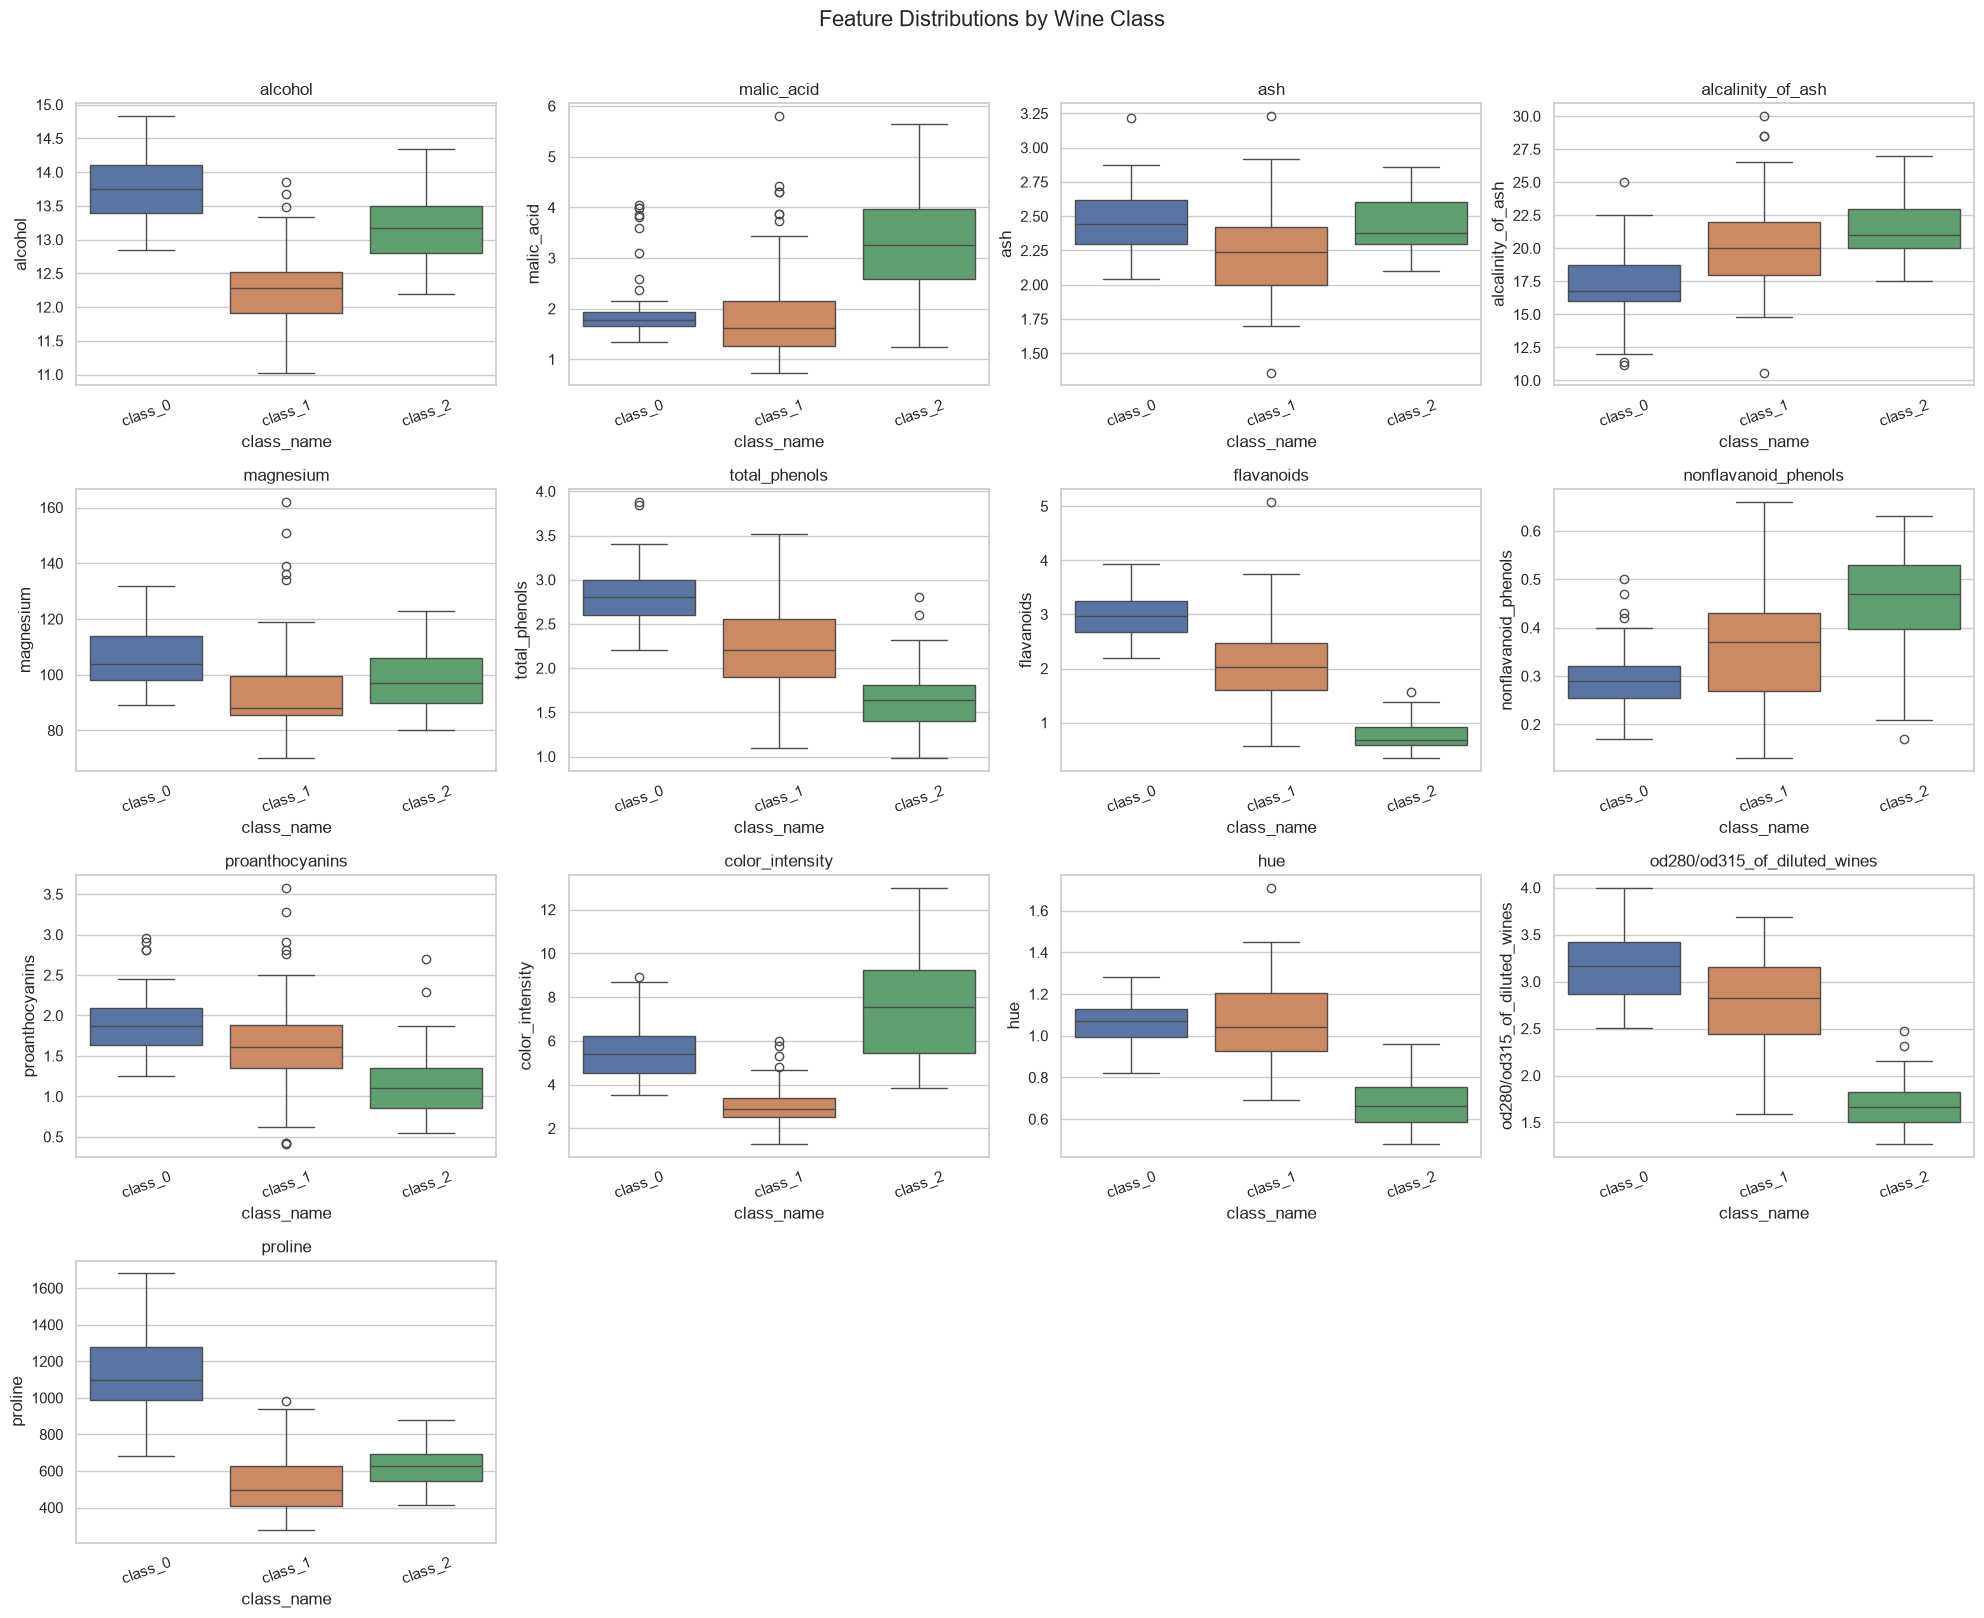

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=target_col, y=col, hue=target_col, legend=False, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=20)
for i in range(len(numeric_cols), len(axes)):
    axes[i].axis("off")
fig.suptitle("Feature Distributions by Wine Class", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 11. Violin Plot

변수가 많기 때문에 대표 변수 5개를 선택하여 클래스별 밀도와 분포를 확인하겠습니다.

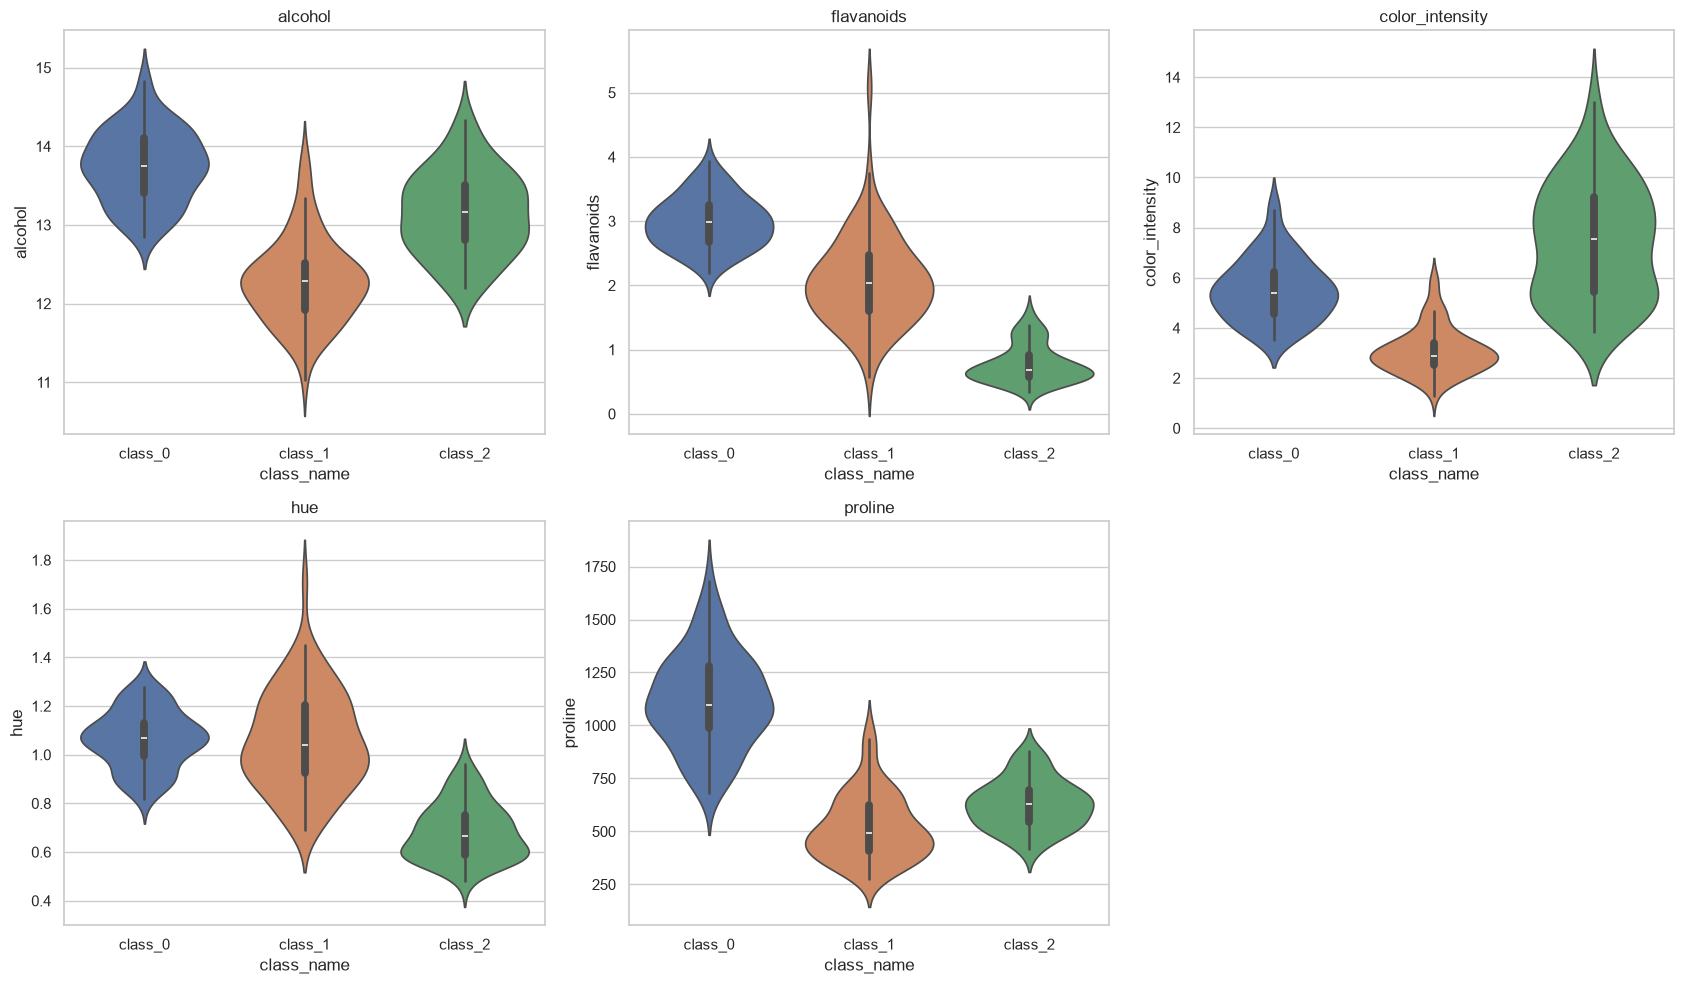

In [11]:
selected_cols = ["alcohol", "flavanoids", "color_intensity", "hue", "proline"]
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
for i, col in enumerate(selected_cols):
    sns.violinplot(data=df, x=target_col, y=col, hue=target_col, legend=False, ax=axes[i])
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

## 12. Pair Plot

13개 전체 변수를 사용하면 그래프가 지나치게 커지므로 대표 변수 5개의 관계를 비교하겠습니다.

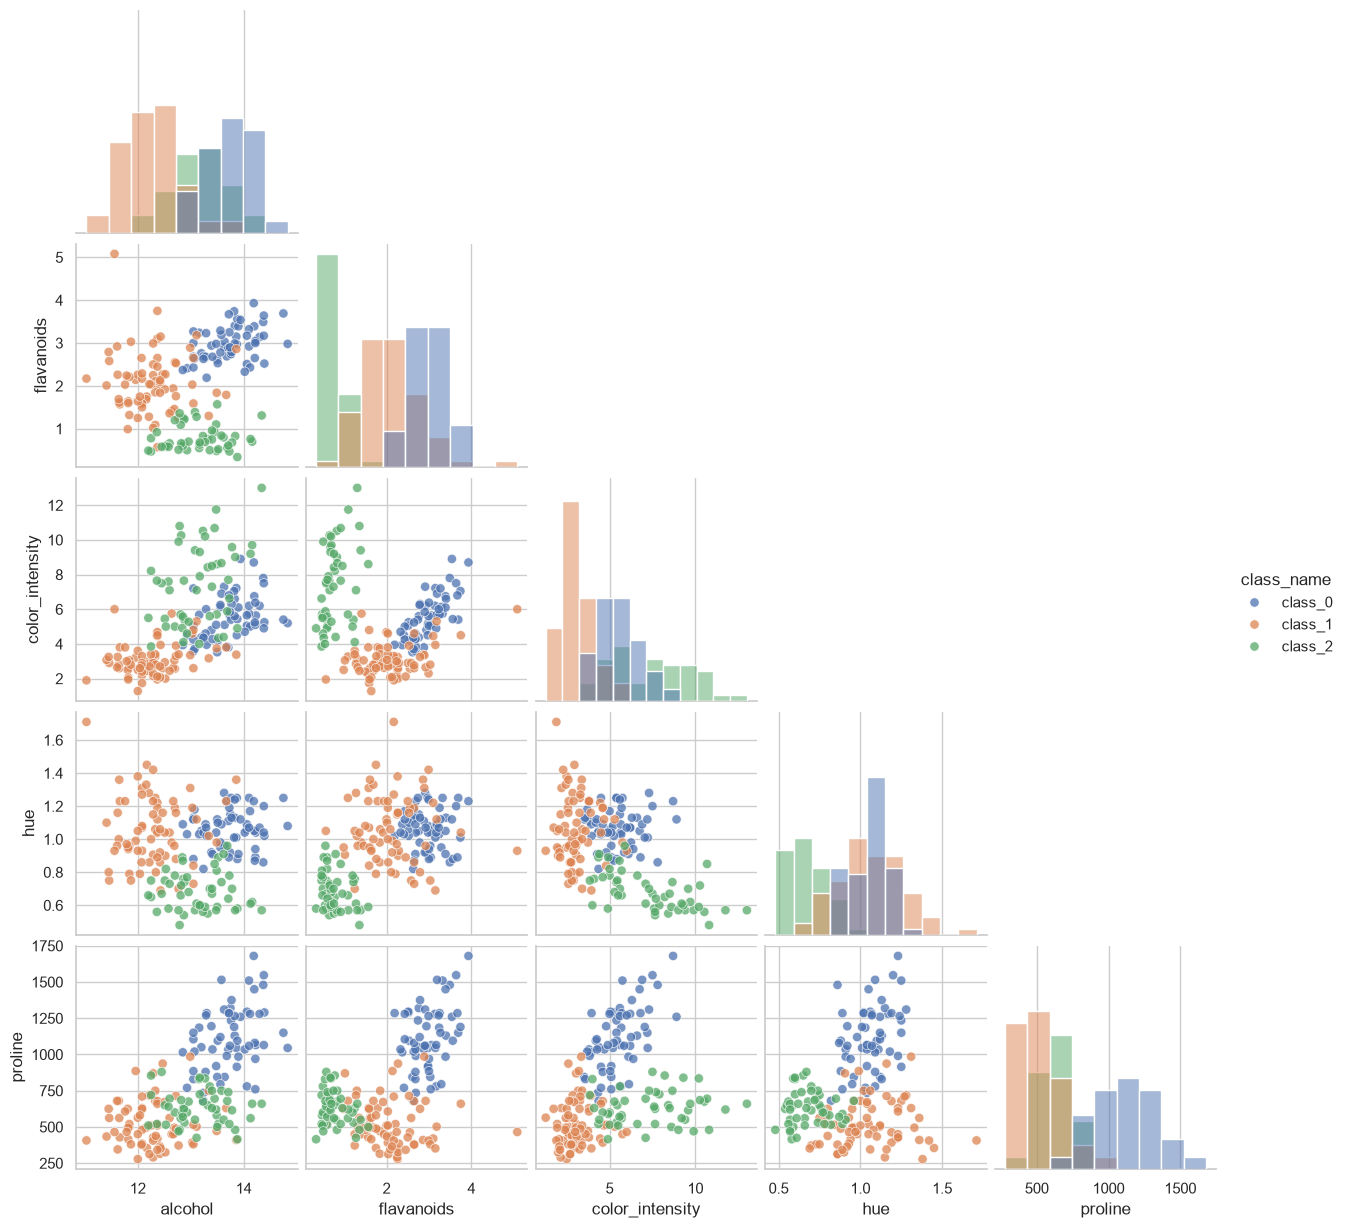

In [12]:
sns.pairplot(df, vars=selected_cols, hue=target_col, diag_kind="hist", corner=True,
             plot_kws={"alpha": 0.75, "s": 45})
plt.show()

## 13. 상관관계 분석

상관계수는 두 수치 변수 사이의 선형 관계를 나타냅니다. 클래스 번호는 범주 코드이므로 계산에서 제외합니다.

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.00,0.09,0.21,-0.31,0.27,0.29,0.24,-0.16,0.14,0.55,-0.07,0.07,0.64
malic_acid,0.09,1.00,0.16,0.29,-0.05,-0.34,-0.41,0.29,-0.22,0.25,-0.56,-0.37,-0.19
ash,0.21,0.16,1.00,0.44,0.29,0.13,0.12,0.19,0.01,0.26,-0.07,0.00,0.22
alcalinity_of_ash,-0.31,0.29,0.44,1.00,-0.08,-0.32,-0.35,0.36,-0.20,0.02,-0.27,-0.28,-0.44
magnesium,0.27,-0.05,0.29,-0.08,1.00,0.21,0.20,-0.26,0.24,0.20,0.06,0.07,0.39
total_phenols,0.29,-0.34,0.13,-0.32,0.21,1.00,0.86,-0.45,0.61,-0.06,0.43,0.70,0.50
flavanoids,0.24,-0.41,0.12,-0.35,0.20,0.86,1.00,-0.54,0.65,-0.17,0.54,0.79,0.49
nonflavanoid_phenols,-0.16,0.29,0.19,0.36,-0.26,-0.45,-0.54,1.00,-0.37,0.14,-0.26,-0.50,-0.31
proanthocyanins,0.14,-0.22,0.01,-0.20,0.24,0.61,0.65,-0.37,1.00,-0.03,0.30,0.52,0.33
color_intensity,0.55,0.25,0.26,0.02,0.20,-0.06,-0.17,0.14,-0.03,1.00,-0.52,-0.43,0.32


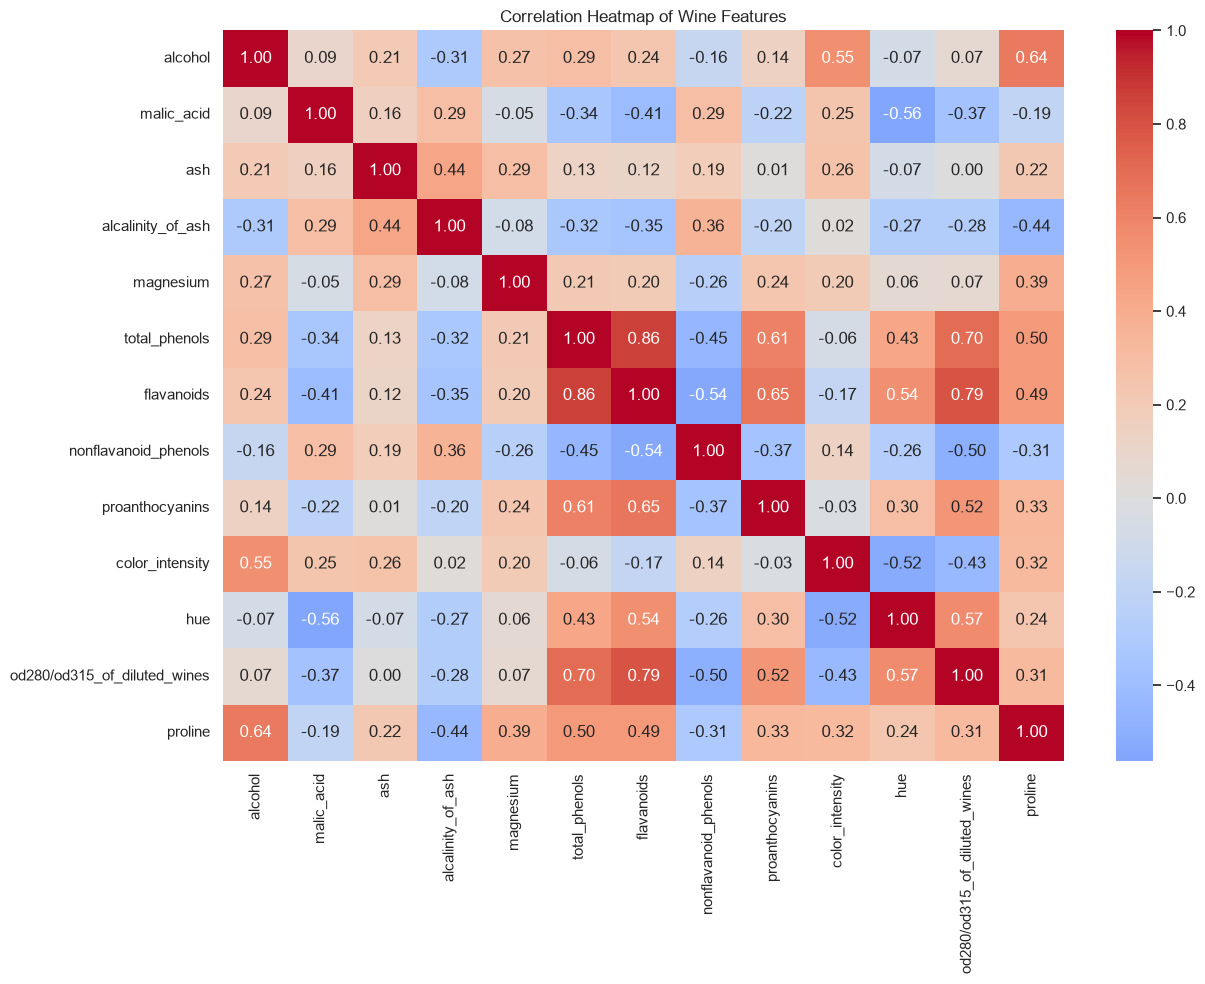

In [13]:
corr = df[numeric_cols].corr()
display(corr.round(2))
plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Wine Features")
plt.tight_layout()
plt.show()

## 14. 주요 변수의 관계 확인

산점도를 이용하여 주요 변수 두 쌍의 관계를 살펴보겠습니다.

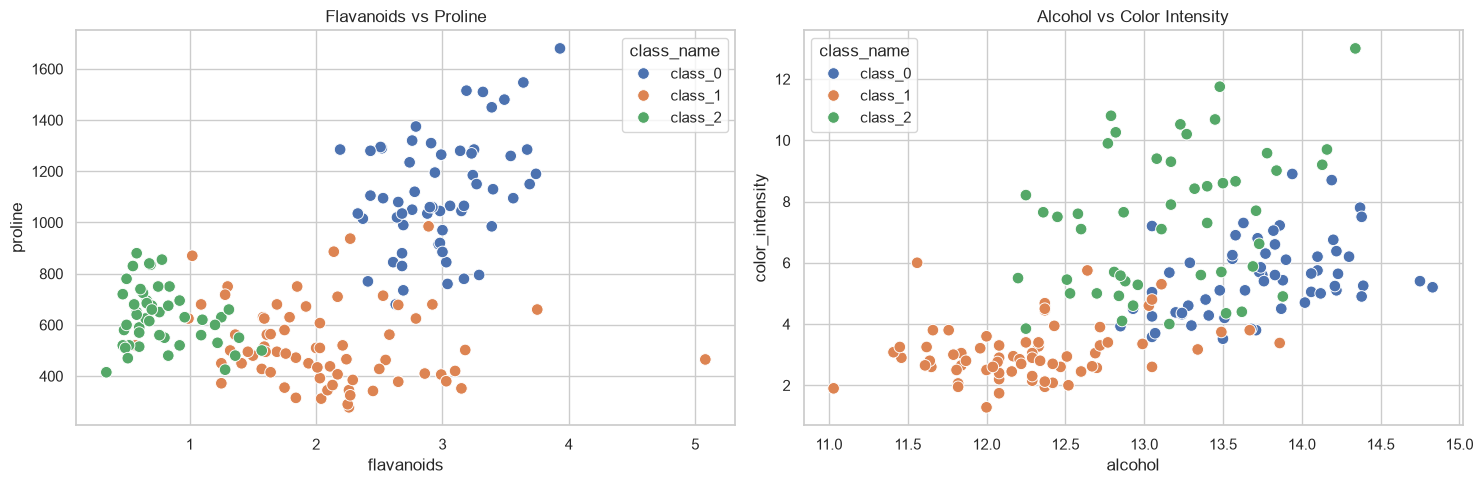

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x="flavanoids", y="proline", hue=target_col, s=70, ax=axes[0])
axes[0].set_title("Flavanoids vs Proline")
sns.scatterplot(data=df, x="alcohol", y="color_intensity", hue=target_col, s=70, ax=axes[1])
axes[1].set_title("Alcohol vs Color Intensity")
plt.tight_layout()
plt.show()

## 15. IQR을 이용한 이상치 탐지

변수별 이상치 후보 개수를 확인합니다. 서로 다른 클래스가 섞여 있으므로 탐지된 값을 바로 삭제하지 않습니다.

In [15]:
rows = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((df[col] < low) | (df[col] > high)).sum())
    rows.append([col, low, high, count])
outlier_summary = pd.DataFrame(rows, columns=["feature", "lower_bound", "upper_bound", "outlier_count"])
display(outlier_summary.sort_values("outlier_count", ascending=False).round(3))

,feature,lower_bound,upper_bound,outlier_count
4,magnesium,59.500,135.500,4
3,alcalinity_of_ash,10.750,27.950,4
9,color_intensity,-1.250,10.670,4
1,malic_acid,-0.617,5.302,3
2,ash,1.689,3.079,3
8,proanthocyanins,0.200,3.000,2
10,hue,0.276,1.626,1
0,alcohol,10.390,15.650,0
5,total_phenols,0.156,4.386,0
7,nonflavanoid_phenols,0.019,0.689,0


## 16. 표준화된 클래스별 평균 비교

특성마다 단위와 범위가 다르므로 표준화한 값으로 클래스별 평균을 비교하겠습니다.

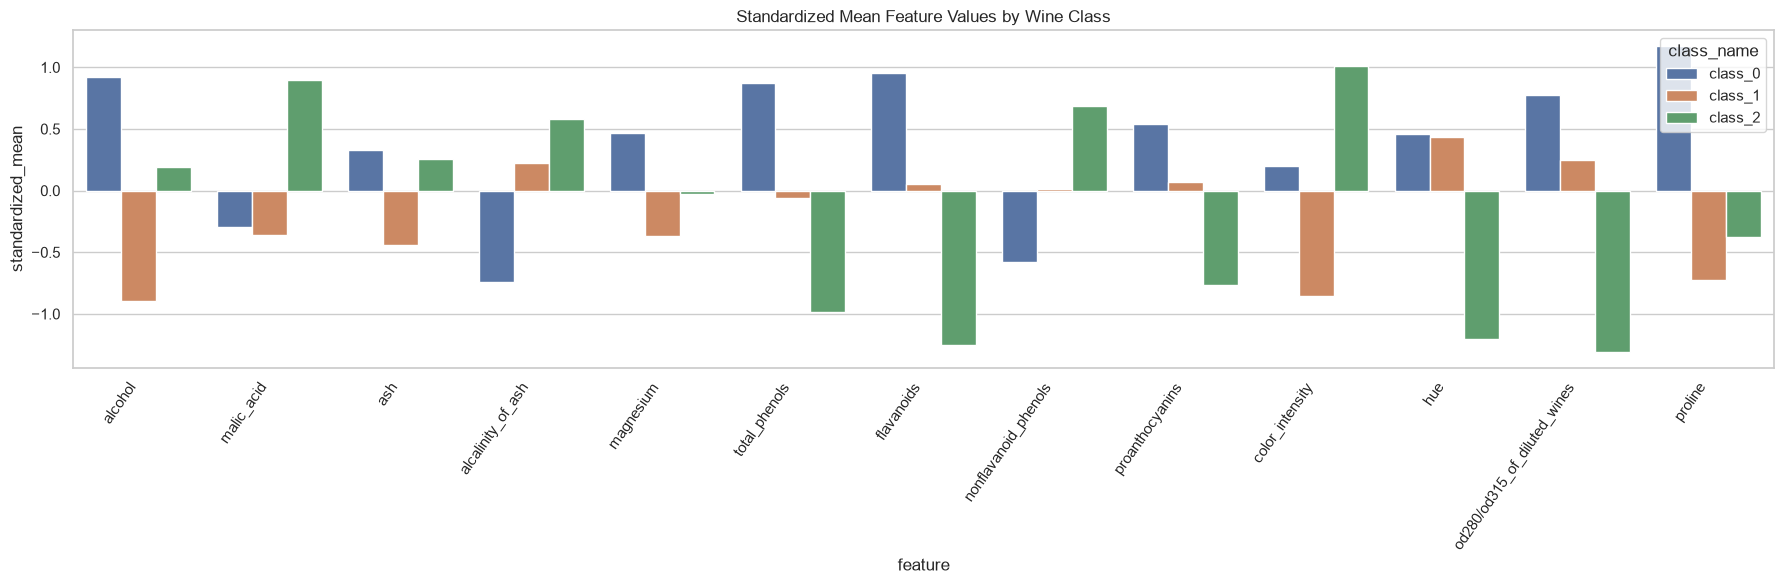

In [16]:
scaled = pd.DataFrame(StandardScaler().fit_transform(df[numeric_cols]), columns=numeric_cols)
scaled[target_col] = df[target_col]
mean_long = (scaled.groupby(target_col)[numeric_cols].mean().reset_index()
             .melt(id_vars=target_col, var_name="feature", value_name="standardized_mean"))
plt.figure(figsize=(18, 6))
sns.barplot(data=mean_long, x="feature", y="standardized_mean", hue=target_col)
plt.xticks(rotation=55, ha="right")
plt.title("Standardized Mean Feature Values by Wine Class")
plt.tight_layout()
plt.show()

## 17. 변동계수 확인

변동계수는 표준편차를 평균으로 나눈 값으로, 단위가 다른 변수의 상대적인 변동 크기를 비교할 때 참고합니다.

In [17]:
cv = (df[numeric_cols].std() / df[numeric_cols].mean().abs()).sort_values(ascending=False)
display(cv.to_frame("coefficient_of_variation").round(3))

,coefficient_of_variation
flavanoids,0.492
malic_acid,0.478
color_intensity,0.458
proline,0.422
proanthocyanins,0.360
nonflavanoid_phenols,0.344
total_phenols,0.273
od280/od315_of_diluted_wines,0.272
hue,0.239
alcalinity_of_ash,0.171


## 18. 변수별 클래스 분리도 확인

ANOVA F-score를 이용하여 클래스 사이의 평균 차이가 클래스 내부 변동보다 상대적으로 큰 변수를 확인하겠습니다.

In [18]:
f_values, p_values = f_classif(df[numeric_cols], wine.target)
separation = pd.DataFrame({"feature": numeric_cols, "F_score": f_values, "p_value": p_values})
display(separation.sort_values("F_score", ascending=False).round(4))

,feature,F_score,p_value
6,flavanoids,233.9259,0.0
12,proline,207.9204,0.0
11,od280/od315_of_diluted_wines,189.9723,0.0
0,alcohol,135.0776,0.0
9,color_intensity,120.6640,0.0
10,hue,101.3168,0.0
5,total_phenols,93.7330,0.0
1,malic_acid,36.9434,0.0
3,alcalinity_of_ash,35.7716,0.0
8,proanthocyanins,30.2714,0.0


## 19. EDA 결과 정리

이번 실습에서는 Wine 데이터의 구조와 품질을 확인하고, 13개 화학 성분의 분포와 클래스별 차이를 살펴보았습니다.

- 데이터는 178개의 관측값, 13개의 수치 변수, 3개의 클래스로 구성되어 있습니다.
- 결측치는 없으며 클래스별 데이터 수에는 약간의 차이가 있습니다.
- 변수마다 측정 단위와 값의 범위가 달라 평균 비교에는 표준화가 필요했습니다.
- `flavanoids`, `proline`, `color_intensity` 등의 변수에서 클래스별 분포 차이를 확인할 수 있습니다.
- IQR로 탐지된 값은 특정 클래스의 특성일 수 있으므로 바로 삭제하지 않습니다.

EDA를 통해 데이터를 먼저 이해하면 이후 분류 모델에서 필요한 전처리와 변수를 판단하는 데 도움이 됩니다.